In [21]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt

In [22]:
df = pd.read_json('schooling-datasets/schooling_frames.json').T

In [23]:
df

,px,py,vx,vy,onfish
1,"[1493.603175, 1323.301887, 809.053763, 545.316...","[385.82539699999995, 474.95597499999997, 663.3...","[-0.9002512464994151, -0.7586642466887621, -0....","[-0.43537075369878503, -0.6514818192368621, 0....","[97196, 97975, 98320, 98324, 98372, 98500, 985..."
2,"[1491.032967, 1321.263768, 805.869637, 542.48,...","[384.58241799999996, 473.20579699999996, 663.9...","[-0.8791929815444851, -0.8006143900733611, -0....","[-0.47646584473907205, -0.599179938255162, -0....","[97196, 97975, 98320, 98324, 98372, 98500, 985..."
3,"[1487.138577, 1319.415301, 804.013962, 540.356...","[382.47191, 471.822404, 663.877836, 439.850980...","[-0.869508388495266, -0.8731549529067171, -0.9...","[-0.49391817372553204, -0.48744274352427003, 0...","[97196, 97975, 98320, 98324, 98372, 98500, 985..."
4,"[1483.960573, 1317.033033, 800.738211, 537.589...","[380.66666699999996, 470.49249199999997, 664.2...","[-0.8931985703604871, -0.964267406431446, -0.9...","[-0.449662444402443, -0.26493087569019, 0.1661...","[97196, 97975, 98320, 98324, 98372, 98500, 985..."
5,"[1480.973485, 1312.932153, 798.532051, 535.153...","[379.162879, 469.36578199999997, 664.600962, 4...","[-0.9517217013186771, -0.9996788945271631, -0....","[-0.30696221793419803, 0.025339846821743003, 0...","[97196, 97975, 98320, 98324, 98372, 98500, 985..."
...,...,...,...,...,...
4996,"[175.473054, 557.972603, 816.508571, 788.18852...","[631.776447, 341.80137, 467.44000000000005, 67...","[0.37104710017976306, -0.99984114301375, -0.74...","[0.928614047625916, 0.017823824981094, -0.6638...","[108829, 110085, 110358, 110521, 110623, 11085..."
4997,"[176.801498, 556.302632, 815.344633, 789.14321...","[635.101124, 341.83114, 466.40678, 672.5925930...","[0.33594738429716003, -0.997698387123612, -0.7...","[0.9418807541211871, -0.067808025564402, -0.67...","[108829, 110085, 110358, 110521, 110623, 11085..."
4998,"[177.998084, 555.605856, 814.378871, 790.94949...","[638.455939, 341.78378399999997, 465.52459, 67...","[0.30406317404181105, -0.9965197269022431, -0....","[0.952651870407872, -0.083357266597925, -0.639...","[108829, 110085, 110358, 110521, 110623, 11085..."
4999,"[178.871377, 555.156989, 813.459963, 792.18357...","[641.192029, 341.74623699999995, 464.759777, 6...","[0.37901643024062004, -0.9999285807805041, -0....","[0.9253899424608291, -0.011951290235179001, -0...","[108829, 110085, 110358, 110521, 110623, 11085..."


In [27]:
def extract_fish_tracks(df):
    """Build per-fish dict: fish_id -> lists of frame, px, py, vx, vy."""
    tracks = {}
    for frame_idx, row in df.iterrows():
        for fish_id, px, py, vx, vy in zip(
            row["onfish"], row["px"], row["py"], row["vx"], row["vy"]
        ):
            if fish_id not in tracks:
                tracks[fish_id] = {
                    "frame": [],
                    "px": [],
                    "py": [],
                    "vx": [],
                    "vy": [],
                }
            t = tracks[fish_id]
            t["frame"].append(int(frame_idx))
            t["px"].append(px)
            t["py"].append(py)
            t["vx"].append(vx)
            t["vy"].append(vy)
    return tracks


def extract_frame_dict(df):
    """Build per-frame dict: frame -> arrays for all fish in that frame."""
    frames = {}
    for frame_idx, row in df.iterrows():
        frames[int(frame_idx)] = {
            "fish_ids": list(row["onfish"]),
            "px": list(row["px"]),
            "py": list(row["py"]),
            "vx": list(row["vx"]),
            "vy": list(row["vy"]),
        }
    return frames


fish_tracks = extract_fish_tracks(df)
frames = extract_frame_dict(df)

print(f"{len(fish_tracks)} unique fish, {len(frames)} frames")
print(f"example fish {next(iter(fish_tracks))}:")
for k, v in fish_tracks[next(iter(fish_tracks))].items():
    print(f"  {k}: {v[:3]} ... ({len(v)} points)")

10751 unique fish, 5000 frames
example fish 97196:
  frame: [1, 2, 3] ... (397 points)
  px: [1493.603175, 1491.032967, 1487.138577] ... (397 points)
  py: [385.82539699999995, 384.58241799999996, 382.47191] ... (397 points)
  vx: [-0.9002512464994151, -0.8791929815444851, -0.869508388495266] ... (397 points)
  vy: [-0.43537075369878503, -0.47646584473907205, -0.49391817372553204] ... (397 points)


Animation size has reached 21069136 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


KeyboardInterrupt: 

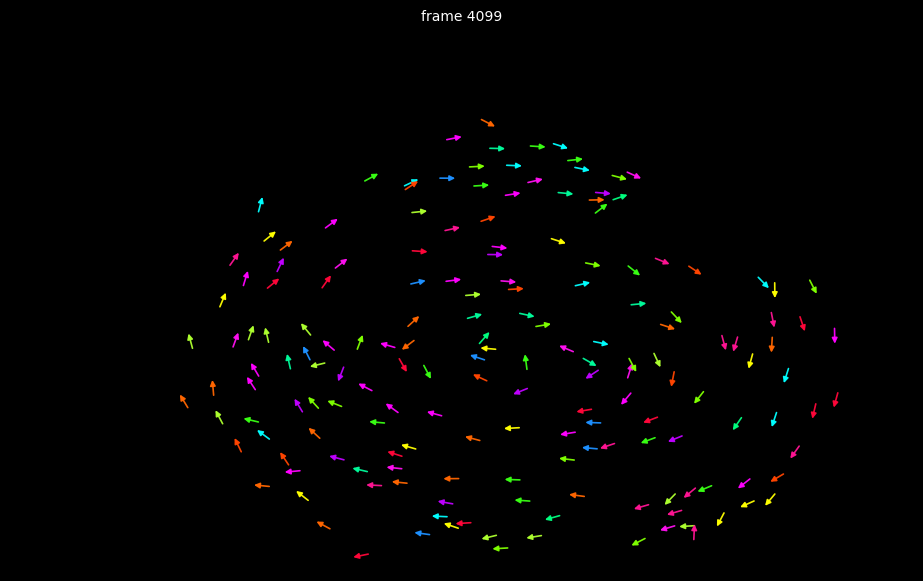

In [28]:
from matplotlib import animation
from matplotlib.patches import FancyArrowPatch
from IPython.display import HTML

# Bright neon palette — each fish keeps a stable color via its id
NEON_COLORS = [
    "#39FF14", "#FF10F0", "#00FFFF", "#FFFF00", "#FF6600",
    "#BF00FF", "#FF073A", "#7FFF00", "#FF1493", "#00FF7F",
    "#FF4500", "#1E90FF", "#ADFF2F", "#FF00FF", "#00FA9A",
]


def fish_color(fish_id):
    return NEON_COLORS[fish_id % len(NEON_COLORS)]


def make_fish_animation(
    df,
    *,
    fps=30,
    arrow_scale=40,
    dot_size=18,
    frame_step=1,
):
    """Animate fish positions (dots) and velocity arrows on a black background."""
    frame_ids = df.index[::frame_step].astype(int)
    xlim = (df["px"].explode().astype(float).min() - 20,
            df["px"].explode().astype(float).max() + 20)
    ylim = (df["py"].explode().astype(float).min() - 20,
            df["py"].explode().astype(float).max() + 20)

    fig, ax = plt.subplots(figsize=(12, 7), facecolor="black")
    ax.set_facecolor("black")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.axis("off")

    scatter = ax.scatter([], [], s=dot_size, edgecolors="white", linewidths=0.3)
    arrows = []

    def init():
        scatter.set_offsets(np.empty((0, 2)))
        scatter.set_facecolors([])
        return [scatter, *arrows]

    def update(i):
        nonlocal arrows
        for a in arrows:
            a.remove()
        arrows = []

        frame = int(frame_ids[i])
        row = df.loc[frame]
        px = np.asarray(row["px"], dtype=float)
        py = np.asarray(row["py"], dtype=float)
        vx = np.asarray(row["vx"], dtype=float)
        vy = np.asarray(row["vy"], dtype=float)
        ids = row["onfish"]
        colors = [fish_color(fid) for fid in ids]

        scatter.set_offsets(np.column_stack([px, py]))
        scatter.set_facecolors(colors)

        for x, y, u, v, c in zip(px, py, vx, vy, colors):
            arr = FancyArrowPatch(
                (x, y),
                (x + u * arrow_scale, y + v * arrow_scale),
                arrowstyle="-|>",
                mutation_scale=8,
                linewidth=1.2,
                color=c,
                alpha=0.95,
            )
            ax.add_patch(arr)
            arrows.append(arr)

        ax.set_title(f"frame {frame}", color="white", fontsize=10, pad=8)
        return [scatter, *arrows]

    anim = animation.FuncAnimation(
        fig,
        update,
        init_func=init,
        frames=len(frame_ids),
        interval=1000 / fps,
        blit=False,
    )
    return anim, fig


# Preview in notebook (every 2nd frame keeps it responsive)
anim, fig = make_fish_animation(df, fps=30, frame_step=2)
HTML(anim.to_jshtml())

saved schooling-datasets/fish_animation.mp4


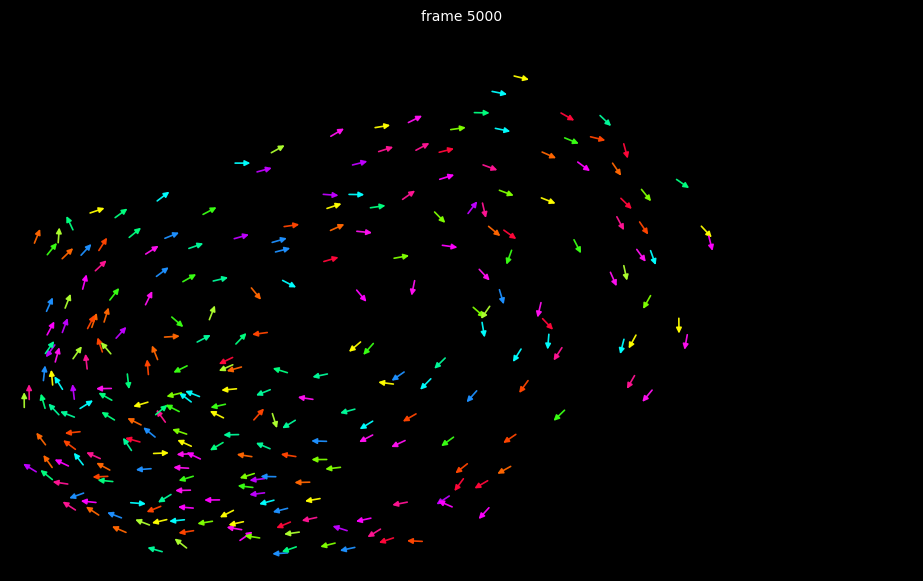

In [26]:
# Save full animation to mp4 (requires ffmpeg)
anim_full, _ = make_fish_animation(df, fps=30, frame_step=1)
anim_full.save(
    "schooling-datasets/fish_animation.mp4",
    writer="ffmpeg",
    dpi=120,
    savefig_kwargs={"facecolor": "black"},
)
print("saved schooling-datasets/fish_animation.mp4")